In [85]:
# import des bibliothèques nécessaires
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import matplotlib.pyplot as plt
import chardet
from collections import Counter

np.random.seed(42)

In [86]:
with open ('Speed+Dating+Data.csv', 'rb') as f:
    raw_data = f.read()
    df = chardet.detect(raw_data)

In [87]:
# Module de détection de codage
detect_encoding = df['encoding'] 
confidence = df['confidence']
print(f"Detected encoding: {detect_encoding} {confidence:.2%}")

Detected encoding: MacRoman 73.00%


In [88]:
# chargement base de données
df = pd.read_csv('Speed+Dating+Data.csv', encoding=detect_encoding)
df.info() # info sur la base de données
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000
max,552.000000,22.000000,1.000000,44.000000,2.000000,21.000000,22.000000,22.000000,22.000000,22.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [89]:
# Création de statistiques descriptives de la base de données
df.describe()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000
max,552.000000,22.000000,1.000000,44.000000,2.000000,21.000000,22.000000,22.000000,22.000000,22.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [90]:
# sélection colonnes
filtrebase = df[['gender', 'age', 'goal', 'match']].dropna()

# Séparation entre effectif masculin et féminin
basemale = filtrebase[filtrebase['gender'] == 1] # création base masculine
basefemale = filtrebase[filtrebase['gender'] == 0] # création base féminine

# Séparation entre rencontres "match" et "no match" 
matched = filtrebase[filtrebase['match'] == 1]['gender'].dropna()
no_matched = filtrebase[filtrebase['match'] == 0]['gender'].dropna()

# Affichage des résultats
print(f"Hommes : {basemale['goal'].count():.0f}")
print(f"Femmes : {basefemale['goal'].count():.0f}")
print(f"Match : {matched.count():.0f}")
print(f"No match : {no_matched.count():.0f}")

Hommes : 4164
Femmes : 4103
Match : 1361
No match : 6906


In [91]:
# affichage résultats pour les hommes
print("Répartition hommes selon motif d'inscription")
print(basemale.groupby('goal').count())
print()
# affichage résultats pour les femmes
print("Répartition femmes selon motif d'inscription") 
print(basefemale.groupby('goal').count())

Répartition hommes selon motif d'inscription
      gender   age  match
goal                     
1.0     1739  1739   1739
2.0     1365  1365   1365
3.0      424   424    424
4.0      172   172    172
5.0      234   234    234
6.0      230   230    230

Répartition femmes selon motif d'inscription
      gender   age  match
goal                     
1.0     1665  1665   1665
2.0     1647  1647   1647
3.0      197   197    197
4.0      129   129    129
5.0      276   276    276
6.0      189   189    189


In [92]:
# graphique du cumul des inscrits des 2 sexes
custom_colors =[ '#e74c3c','#3498db' ]
fig = px.histogram(
    filtrebase,
    x='age',
    title = "Répartition hommes/femmes selon l'age",
    color_discrete_sequence = custom_colors,
    color='gender') # graphique des 2 sexes cumulés par âge

fig.update_layout(xaxis_title="Age"),
fig.update_layout(yaxis_title="Nombre")
fig.update_layout(title_x=0.5)

fig.show()

In [93]:
# on constate les effectifs les plus importants entre 22 et 30 ans 
# il y a quelques femmes de 55 ans qu'on excluera de l'étude car très éloignées des autres

In [94]:
data1 = basemale.groupby('goal').count() # répartition des hommes par motif d'inscription
data2 = basefemale.groupby('goal').count() # répartition des femmes par motif d'inscription

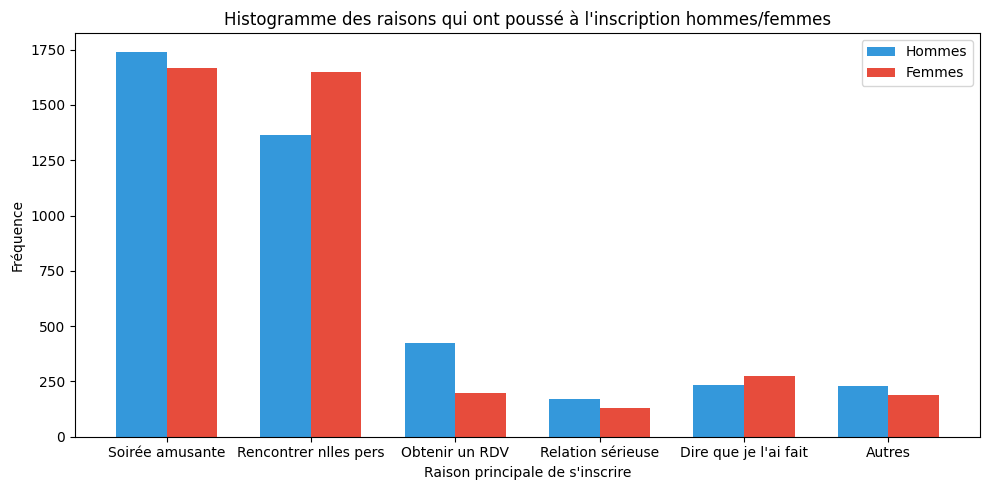

In [95]:
# liste des motifs d'inscriptions
labelalias= ["Soirée amusante", "Rencontrer nlles pers", "Obtenir un RDV", "Relation sérieuse", "Dire que je l'ai fait", "Autres"]
# Histogramme des raisons qui ont poussé à l'inscription
x = np.arange(len(labelalias))
width = 0.35
 
plt.figure(figsize=(10, 5))
plt.bar(x - (width/2), data1['gender'], width, label='Hommes', color='#3498db')
plt.bar(x + (width/2), data2['gender'], width, label='Femmes', color='#e74c3c')

plt.title("Histogramme des raisons qui ont poussé à l'inscription hommes/femmes")
plt.xlabel("Raison principale de s'inscrire")
plt.ylabel('Fréquence')
plt.xticks(x, labelalias)
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
# on constate que chez les hommes, la raison principale d'inscription est de passer une soirée amusante, puis de rencontrer de nouvelles personnes
# chez les femmes, ces 2 critères sont presque équivalents 

In [97]:
extrdh = basemale[basemale['age']<43]
extrdf = basefemale[basefemale['age']<43] # réduction des valeurs extrêmes des femmes (on garde seulement < 43 ans)

In [98]:
# préparation des bornes du graphique
minage = min(min(extrdh['age']), min(extrdf['age'])) # age minimal quelque soit le sexe
maxage = max(max(extrdh['age']), max(extrdf['age'])+2) # age maximal quelque soit le sexe

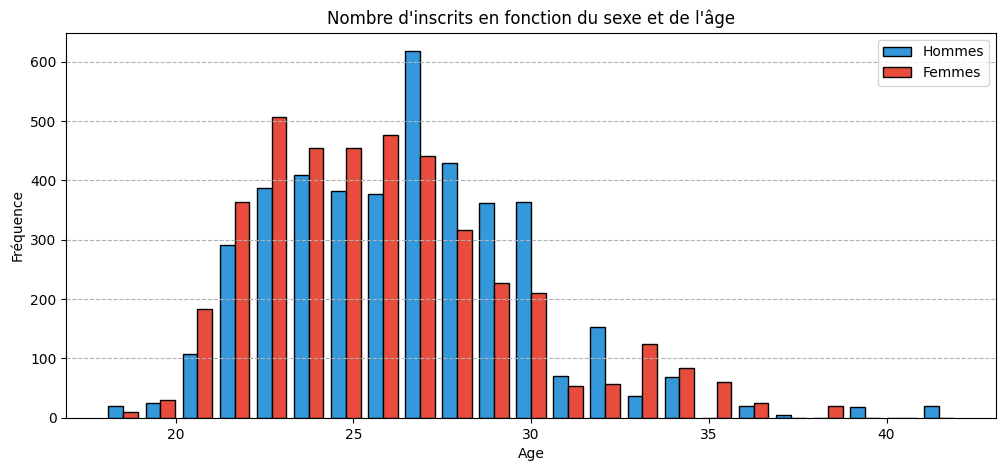

In [99]:
# Histogramme du nombre d'inscrits en fonction du sexe et de l'age
bins = np.linspace(minage, maxage, 24)
alpha = 1
plt.figure(figsize=(12, 5))
plt.hist([extrdh['age'], extrdf['age']], bins=bins, alpha=alpha , label=['Hommes', 'Femmes'], color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title("Nombre d'inscrits en fonction du sexe et de l'âge")
plt.xlabel("Age")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

In [100]:
# jusqu'à 26 ans, on constate qu'il y a plus de femmes que d'hommes
# la tendance s'inverse après les 26 ans, à quelques exceptions près

In [101]:
# filtrage de la base pour sortir les critères préférés recherchés dans le sexe opposé
filtrecrit = df[['gender', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']].dropna()

# Séparation entre effectif masculin et féminin
basecritmale = filtrecrit[filtrecrit['gender'] == 1] # création base masculine
basecritfemale = filtrecrit[filtrecrit['gender'] == 0] # création base féminine

In [102]:
# création base de données à partir des résultats des critères préférés
crith = [basecritmale['attr1_1'].mean(), basecritmale['sinc1_1'].mean(), basecritmale['intel1_1'].mean(),basecritmale['fun1_1'].mean(), basecritmale['amb1_1'].mean(), basecritmale['shar1_1'].mean()]
critf = [basecritfemale['attr1_1'].mean(), basecritfemale['sinc1_1'].mean(), basecritfemale['intel1_1'].mean(),basecritfemale['fun1_1'].mean(), basecritfemale['amb1_1'].mean(), basecritfemale['shar1_1'].mean()]

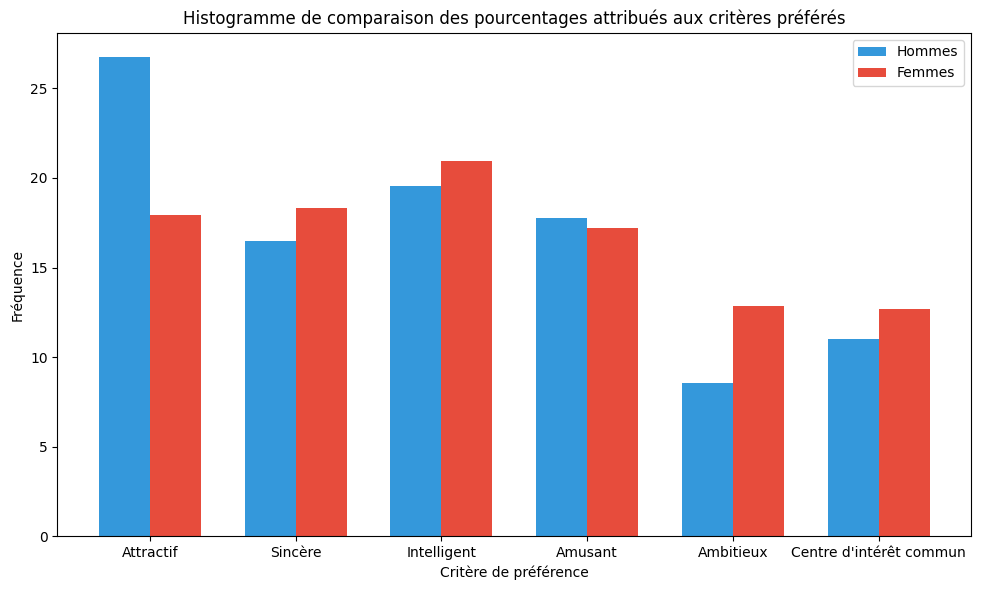

In [103]:
# liste des critères préférés recherchés
labelalias2= ["Attractif", "Sincère", "Intelligent", "Amusant", "Ambitieux", "Centre d'intérêt commun"]
# histogramme de comparaison des pourcentages attribués aux critères préférés
x = np.arange(len(labelalias))
width = 0.35
 
plt.figure(figsize=(10, 6))
plt.bar(x - (width/2), crith, width, label='Hommes', color='#3498db')
plt.bar(x + (width/2), critf, width, label='Femmes', color='#e74c3c')

plt.title('Histogramme de comparaison des pourcentages attribués aux critères préférés')
plt.xlabel("Critère de préférence")
plt.ylabel('Fréquence')
plt.xticks(x, labelalias2)
plt.legend()
plt.tight_layout()
plt.show()

In [104]:
# filtrage de la base pour sortir les critères préférés que recherche le sexe opposé selon eux
filtrecrit2 = df[['gender', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1']].dropna()

# Séparation entre effectif masculin et féminin
basecritmale2 = filtrecrit2[filtrecrit2['gender'] == 1] # création base masculine
basecritfemale2 = filtrecrit2[filtrecrit2['gender'] == 0] # création base féminine

In [105]:
# création base de données à partir des résultats des critères préférés par le sexe opposé selon eux
crith2 = [basecritmale2['attr2_1'].mean(), basecritmale2['sinc2_1'].mean(), basecritmale2['intel2_1'].mean(), basecritmale2['fun2_1'].mean(), basecritfemale2['amb2_1'].mean(), basecritmale2['shar2_1'].mean()]
critf2 = [basecritfemale2['attr2_1'].mean(), basecritfemale2['sinc2_1'].mean(), basecritfemale2['intel2_1'].mean(), basecritfemale2['fun2_1'].mean(), basecritfemale2['amb2_1'].mean(), basecritfemale2['shar2_1'].mean()]

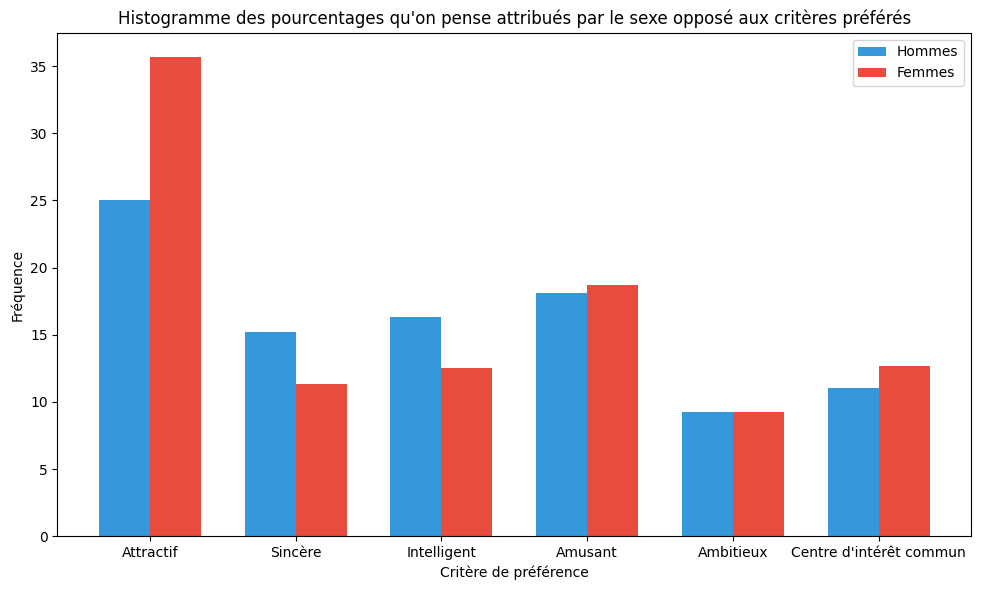

In [106]:
# histogramme des critères préférés qu'on pense chercher par le sexe opposé
x = np.arange(len(labelalias))
width = 0.35
 
plt.figure(figsize=(10, 6))
plt.bar(x - (width/2), crith2, width, label='Hommes', color='#3498db')
plt.bar(x + (width/2), critf2, width, label='Femmes', color='#e74c3c')

plt.title("Histogramme des pourcentages qu'on pense attribués par le sexe opposé aux critères préférés")
plt.xlabel("Critère de préférence")
plt.ylabel('Fréquence')
plt.xticks(x, labelalias2)
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
# Le premier des critères pour les hommes est l'attractivité à environ 27%, mais les femmes estiment que c'est 36 % des hommes pour qui l'attractivité prédomine.
# Les hommes pensent que le premier critère des femmes est l'attractivité à 25 %, alors qu'en réalité, les femmes privilégient l'intelligence et la sincérité sur l'attractivité 
# L'importance d'un centre d'intérêt commun n'apparaît que dans environ 10% des réponses des hommes, et à peine plus chez les femmes
# L'ambition est un critère plus important pour les femmes que pour les hommes

In [108]:
# Détermination de l'age le plus élevé dans ceux qui ont matché
print(max(filtrebase[filtrebase['match']==1]['age']))

42.0


In [109]:
# filtre de la base pour travail sur les matches
filtrebase2 = filtrebase[filtrebase['age']<43]

In [110]:
# préparation des bornes du graphique
minage2 = min(min(filtrebase2['age']), min(filtrebase2['age'])) # age minimal quelque soit le sexe
maxage2 = max(max(filtrebase2['age']), max(filtrebase2['age'])+2) # age maximal quelque soit le sexe

In [111]:
# filtre de ceux qui ont matché 
matchok = filtrebase2[filtrebase2['match']==1]

In [112]:
# Détermination de l'age moyen des gens qui ont matché
print(f"Age moyen de match : {matchok['age'].mean():.2f}")

Age moyen de match : 26.08


In [113]:
matchokh = matchok[matchok['gender']==1] # filtre des hommes qui ont matché
matchokf = matchok[matchok['gender']==0] # filtre des femmes qui ont matché

In [114]:
# Détermination de l'age moyen des hommes qui ont matché
print(f"Age moyen de match chez les hommes : {matchokh['age'].mean():.2f}")
print()
# Détermination de l'age moyen des femmes qui ont matché
print(f"Age moyen de match chez les femmes : {matchokf['age'].mean():.2f}")

Age moyen de match chez les hommes : 26.35

Age moyen de match chez les femmes : 25.80


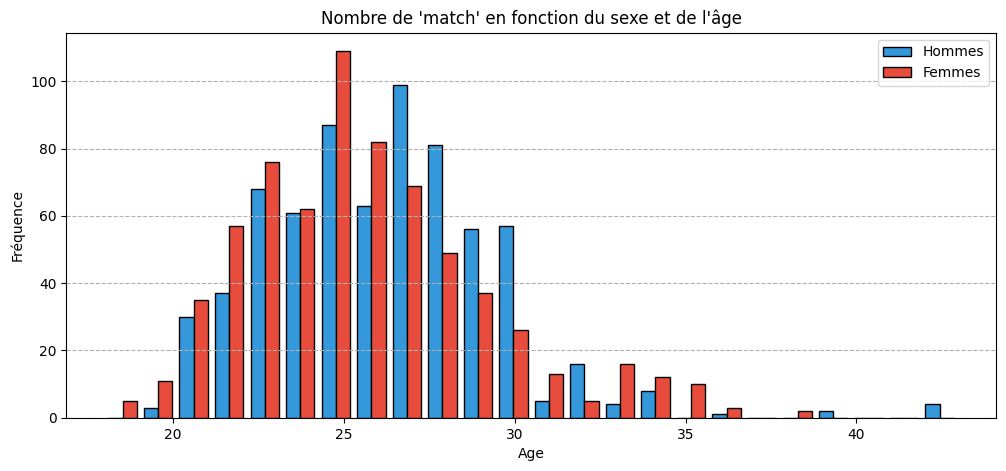

In [115]:
# Histogramme du nombre de match en fonction du sexe et de l'age
bins = np.linspace(minage2, maxage2, 25, endpoint=False)
alpha = 1
plt.figure(figsize=(12,5))
plt.hist([matchokh['age'], matchokf['age']], bins=bins, alpha=alpha , label=['Hommes', 'Femmes'], color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title("Nombre de 'match' en fonction du sexe et de l'âge")
plt.xlabel("Age")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

In [116]:
# L'age où les matches se sont le plus réalisés est de 25 ans pour les femmes et de 27 ans chez les hommes
# Chez les personnes de moins de 27 ans, il y a une plus grande proportion de matches chez les femmes que chez les hommes
# De 27 à 30 ans, la proportion chez les hommes devient plus importante que chez les femmes
# Au-delà de 30 ans, les matches sont peu nombreux, quelque soit le sexe

In [117]:
filtrebase3 = df[['gender', 'age', 'goal', 'match', 'age_o']].dropna()

In [118]:
basematch = filtrebase3[filtrebase3['match']==1]

In [119]:
# Séparation entre effectif masculin et féminin
basemale3 = basematch[basematch['gender'] == 1] # création base masculine
basefemale3 = basematch[basematch['gender'] == 0] # création base féminine

In [120]:
ecarth = basemale3['age']-basemale3['age_o']
ecartf = basefemale3['age']-basefemale3['age_o']

In [121]:
# préparation des bornes du graphique
minage3 = min(ecarth) # ecart minimal
maxage3 = max(ecarth) # ecart maximal

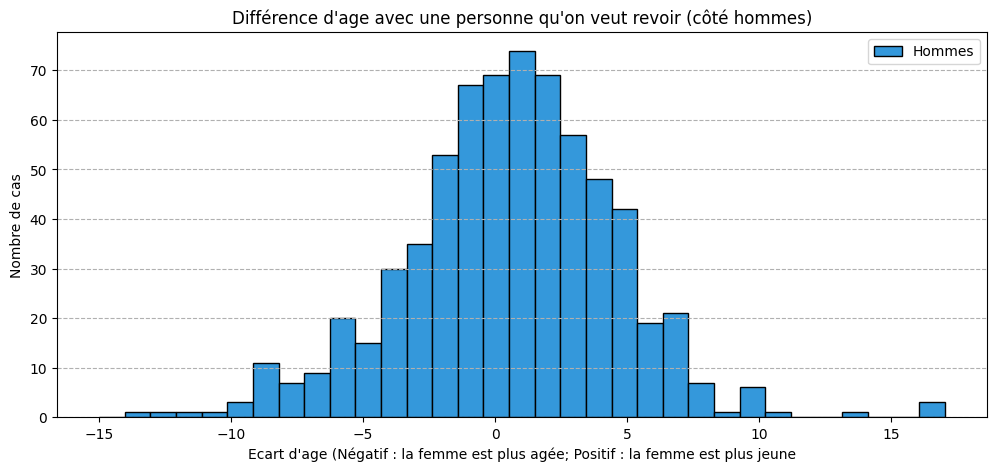

In [122]:
# Histogramme du nombre de
bins = np.linspace(-15, 18, 34, endpoint=False)
alpha = 1
plt.figure(figsize=(12,5))
plt.hist((ecarth), bins=bins, alpha=alpha , label=['Hommes'], color=['#3498db'], edgecolor='black')
plt.title("Différence d'age avec une personne qu'on veut revoir (côté hommes)")
plt.xlabel("Ecart d'age (Négatif : la femme est plus agée; Positif : la femme est plus jeune")
plt.ylabel("Nombre de cas")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

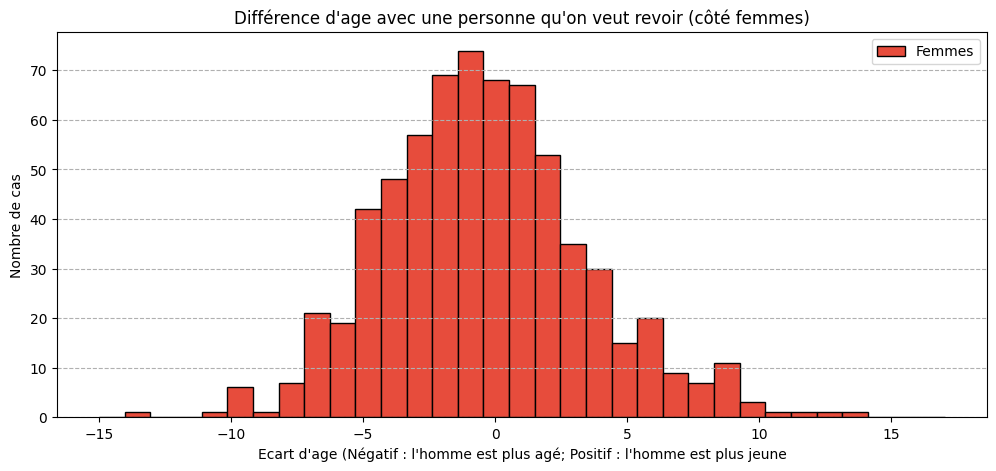

In [123]:
# Histogramme du nombre de
bins = np.linspace(-15, 18, 34, endpoint=False)
alpha = 1
plt.figure(figsize=(12,5))
plt.hist((ecartf), bins=bins, alpha=alpha , label=['Femmes'], color=['#e74c3c'], edgecolor='black')
plt.title("Différence d'age avec une personne qu'on veut revoir (côté femmes)")
plt.xlabel("Ecart d'age (Négatif : l'homme est plus agé; Positif : l'homme est plus jeune")
plt.ylabel("Nombre de cas")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

In [124]:
# On constate que le cas le plus fréquent est celui où l'homme a un an de plus
# Mais les situations où l'homme a de 2 ans de moins à 5 ans de plus que la femme sont fréquentes
# Mais sur l'ensemble, les hommes qui ont matché avec une partenaire, avait un age allant de 14 ans de moins à 17 ans de plus